## Zero-shot Learning for Covid Diagnosis


Zero-shot Learning is a machine learning paradigm in which a model learns to recognize things / classify classes it has not explicitly seen before in training. It is a way to decrease models’ reliance on labeled data. 

COVID-19 chest x-ray diagnosis is a perfect example of zero-shot learning in a medically relevant and low-label setting. The model will learn about covid using x-ray images of other lung diseases and auxiliary information about covid.

### Data
- Training, Validation, & Testing: [coronahack-chest-xraydataset](https://www.kaggle.com/datasets/praveengovi/coronahack-chest-xraydataset) 
- Word Embedding: [FastText Common Crawl bin model](https://www.kaggle.com/datasets/kingarthur7/fasttext-common-crawl-bin-model)

### Approaches

1. image embedding & word embedding
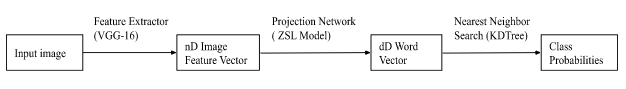
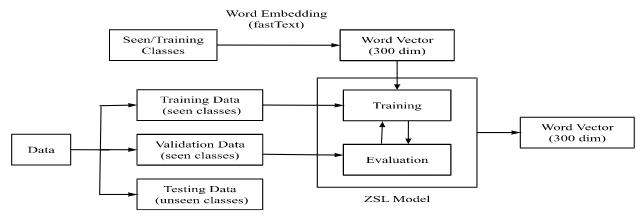
1. CLIP (OpenAI's zero-shot classifier)
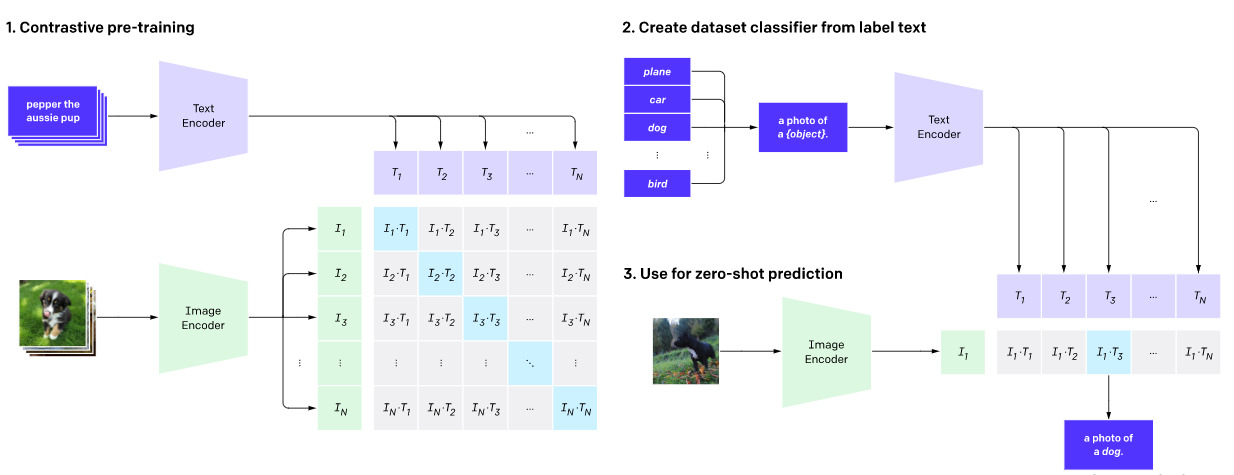

In [1]:
import warnings
warnings.filterwarnings('ignore')
import torch
import fasttext

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.applications import vgg16
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
# from gensim.models import FastText, KeyedVectors
from sklearn.preprocessing import normalize
from sklearn.neighbors import KDTree
from transformers import CLIPProcessor, CLIPModel

### Data Preprocessing & Augmentation

In [2]:
# define labels/classes (seen/train & unseen/zsl classes)
class_train = ['normal', 'viral pneumonia', 'bacterial pneumonia']
class_zsl = ['covid-19']
classes = class_train + class_zsl 

In [3]:
# convert one-word labels to sentences 
# CLIP performs better with full textual descriptions/captions
captions = [f'an x-ray of a {clss} patient' for clss in classes]

In [4]:
# load data
# the dataset doesn't contain a separate folder for each class images
# dataset format is: a single folder for all classes and a csv file for metadata

In [5]:
# data paths
path_metadata = '../input/coronahack-chest-xraydataset/Chest_xray_Corona_Metadata.csv'
path_train = '../input/coronahack-chest-xraydataset/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train'
path_test = '../input/coronahack-chest-xraydataset/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/test'
path_fasttext = '../input/fasttext-common-crawl-bin-model/cc.en.300.bin'
path_test_img = '../input/coronahack-chest-xraydataset/Coronahack-Chest-XRay-Dataset/Coronahack-Chest-XRay-Dataset/train/kjr-21-e24-g003-l-a.jpg'

In [6]:
# read metadata
df_metadata = pd.read_csv(path_metadata, index_col=0)
df_metadata

,X_ray_image_name,Label,Dataset_type,Label_2_Virus_category,Label_1_Virus_category
0,IM-0128-0001.jpeg,Normal,TRAIN,NaN,NaN
1,IM-0127-0001.jpeg,Normal,TRAIN,NaN,NaN
2,IM-0125-0001.jpeg,Normal,TRAIN,NaN,NaN
3,IM-0122-0001.jpeg,Normal,TRAIN,NaN,NaN
4,IM-0119-0001.jpeg,Normal,TRAIN,NaN,NaN
...,...,...,...,...,...
5928,person1637_virus_2834.jpeg,Pnemonia,TEST,NaN,Virus
5929,person1635_virus_2831.jpeg,Pnemonia,TEST,NaN,Virus
5930,person1634_virus_2830.jpeg,Pnemonia,TEST,NaN,Virus
5931,person1633_virus_2829.jpeg,Pnemonia,TEST,NaN,Virus


In [7]:
# fill missing values, drop and rename columns
df_metadata.Label_1_Virus_category.fillna(df_metadata.Label, inplace=True)
df_metadata.Label_2_Virus_category.fillna(df_metadata.Label_1_Virus_category, 
                                          inplace=True)
df_metadata.drop(['Label', 'Label_1_Virus_category'], axis=1, inplace=True)
df_metadata.rename(columns={'X_ray_image_name':  'Filename',
                            'Dataset_type': 'Type',
                            'Label_2_Virus_category': 'Class'}, inplace=True)
df_metadata.Class.replace({'Virus': 'viral pneumonia', 
                           'bacteria': 'bacterial pneumonia',
                           'Normal': 'normal',
                           'COVID-19': 'covid-19'}, inplace=True)
df_metadata

,Filename,Type,Class
0,IM-0128-0001.jpeg,TRAIN,normal
1,IM-0127-0001.jpeg,TRAIN,normal
2,IM-0125-0001.jpeg,TRAIN,normal
3,IM-0122-0001.jpeg,TRAIN,normal
4,IM-0119-0001.jpeg,TRAIN,normal
...,...,...,...
5928,person1637_virus_2834.jpeg,TEST,viral pneumonia
5929,person1635_virus_2831.jpeg,TEST,viral pneumonia
5930,person1634_virus_2830.jpeg,TEST,viral pneumonia
5931,person1633_virus_2829.jpeg,TEST,viral pneumonia


In [8]:
# dataframes (training, validation, testing)
df_train = df_metadata[(df_metadata.Type == 'TRAIN') & 
                    (df_metadata.Class.isin(class_train))].reset_index(drop=True)
df_valid = df_metadata[(df_metadata.Type == 'TEST') & 
                    (df_metadata.Class.isin(class_train))].reset_index(drop=True)
df_zsl = df_metadata[(df_metadata.Class.isin(class_zsl))].reset_index(drop=True) 

In [9]:
# drop Type column
df_train.drop(['Type'], axis=1, inplace=True)
df_valid.drop(['Type'], axis=1, inplace=True)
df_zsl.drop(['Type'], axis=1, inplace=True)
df_train

,Filename,Class
0,IM-0128-0001.jpeg,normal
1,IM-0127-0001.jpeg,normal
2,IM-0125-0001.jpeg,normal
3,IM-0122-0001.jpeg,normal
4,IM-0119-0001.jpeg,normal
...,...,...
5212,person88_virus_167.jpeg,viral pneumonia
5213,person88_virus_166.jpeg,viral pneumonia
5214,person88_virus_165.jpeg,viral pneumonia
5215,person88_virus_164.jpeg,viral pneumonia


In [10]:
# data generators

idg_train = image.ImageDataGenerator(rescale=1/255, rotation_range=10,
                                     zoom_range=[0.75, 1],
                                     brightness_range=(0.8, 1.2) ) 
idg_test = image.ImageDataGenerator(rescale=1/255) 

data_train = idg_train.flow_from_dataframe(dataframe=df_train,
                                           directory=path_train, 
                                           x_col='Filename', 
                                           y_col='Class',
                                           target_size=(224, 224), 
                                           batch_size=32,
                                           shuffle=True, 
                                           class_mode='categorical')
data_valid = idg_test.flow_from_dataframe(dataframe=df_valid, 
                                          directory=path_test, 
                                          x_col='Filename', 
                                          y_col='Class',
                                          target_size=(224, 224), 
                                          batch_size=32, 
                                          shuffle=True, 
                                          class_mode='categorical')
data_zsl = idg_test.flow_from_dataframe(dataframe=df_zsl, 
                                        directory=path_train, 
                                        x_col='Filename', 
                                        y_col='Class',
                                        target_size=(224, 224), 
                                        batch_size=1,  
                                        # class_mode=None
                                        shuffle=False, 
                                        class_mode='categorical')

Found 5217 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
Found 58 validated image filenames belonging to 1 classes.


In [11]:
# get number of batches 

batch_size = 32

if data_train.samples % batch_size:
    n_batches_train = data_train.samples // batch_size + 1
else:
    n_batches_train = data_train.samples // batch_size

if data_valid.samples % batch_size:
    n_batches_valid = data_valid.samples // batch_size + 1
else:
    n_batches_valid = data_valid.samples // batch_size

n_batches_test = data_zsl.samples     # bcz batch size is 1 in test generator

In [12]:
# extract labels from data generators

y_train = list()
for i in range(n_batches_train):
    x_batch, y_batch = next(data_train)
    y_train.extend(y_batch)
y_train = np.array(y_train)

y_valid = list()
for i in range(n_batches_valid): 
    _, y_batch = next(data_valid)
    y_valid.extend(y_batch)
y_valid = np.array(y_valid)

y_zsl = list()
for i in range(n_batches_test):
    _, y_batch = next(data_zsl)
    y_zsl.extend(y_batch)
y_zsl = np.array(y_zsl)

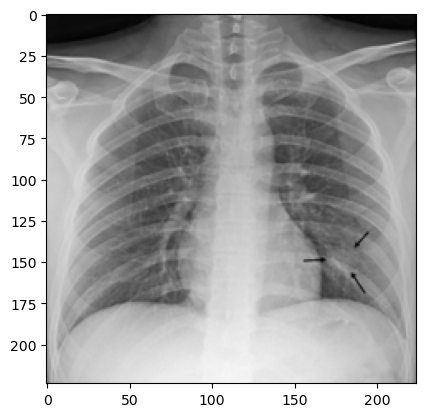

In [13]:
# load test image (covid-19 x-ray)
img_test = image.load_img(path_test_img, 
                          target_size=(224, 224), 
                          interpolation='bilinear')
plt.imshow(img_test)

### Training & Evaluation

### Method 1: Image Embedding & Word Embedding

In [14]:
# Embedding-based ZSL model
# model input = 4096-dimensional image feature vector
# model output = 300-dimensional word vector

In [15]:
# image embedding/feature extraction
# develop feature extractor 

# load pretrained VGG16 for feature extraction
# input_shape = (height, width, channel)
model_vgg = vgg16.VGG16(input_shape=(224, 224, 3),
                        weights='imagenet', 
                        include_top=True)        

# remove last two layers to extract features (4096D)
model_fe = Model(name='feature_extractor', 
                 inputs=model_vgg.input, 
                 outputs=model_vgg.layers[-3].output)
model_fe.summary()

553467096/553467096 [==============================] - 22s 0us/step
Model: "feature_extractor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                               

In [16]:
# save model
model_fe.save('model_fe.h5')

In [17]:
# extract features (4096D)
x_train = model_fe.predict(data_train)
x_valid = model_fe.predict(data_valid)
x_zsl = model_fe.predict(data_zsl)

58/58 [==============================] - 17s 290ms/step


In [18]:
# normalize features
x_train = normalize(x_train, norm='l2')
x_valid = normalize(x_valid, norm='l2')
x_zsl = normalize(x_zsl, norm='l2')

In [19]:
# word/class embedding
# get word vector (300D) using fastText pre-trained on Common Crawl Dataset
# fastText works well with rare words and can derive word vectors for unknown words or out-of-vocabulary words

model_fasttext = fasttext.load_model(path_fasttext)
word_vec = list()
for clss in classes:
    word_vec.append(model_fasttext[clss])
word_vec = np.asarray(word_vec, dtype=float)
word_vec

array([[ 0.02538359,  0.07411885, -0.02161653, ...,  0.05772371,
        -0.00761599,  0.02083593],
       [ 0.01018097,  0.01494264,  0.04398041, ...,  0.00886347,
        -0.01134837, -0.0118666 ],
       [-0.00071981, -0.00333452, -0.00273251, ...,  0.00300197,
        -0.01294545, -0.01307176],
       [ 0.013856  , -0.00348851, -0.01187718, ...,  0.04416551,
         0.02973056,  0.00118219]])

In [20]:
# convert 1D zsl labels to 300D word vectors
y_zsl = np.array([word_vec[3] for _ in range(len(y_zsl))])

In [21]:
# develop zsl model to get word vector (300D) from feature vector (4096D)

model_zsl = Sequential(name='zsl')
model_zsl.add(Dense(1024, input_shape=(4096,), activation='relu'))
model_zsl.add(BatchNormalization())
model_zsl.add(Dropout(0.8))
model_zsl.add(Dense(512, activation='relu'))
model_zsl.add(Dropout(0.5))
model_zsl.add(Dense(300, activation='relu'))

# last layer weights → transpose of Word2Vecs of the training classes
# Transpose is to match shape (input, otput). word vector is (3, 300) & model is (300, 3)

def custom_kernel_init(shape, dtype=None):
    return word_vec[:3].T


model_zsl.add(Dense(units=3,                # 3 = no. of train classes
                    activation='softmax', 
                    trainable=False, 
                    kernel_initializer=custom_kernel_init)) 
model_zsl.summary()

Model: "zsl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1024)              4195328   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 300)               153900    
                                                               

In [22]:
# train model
model_zsl.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['categorical_accuracy', 'top_k_categorical_accuracy'])
hist = model_zsl.fit(x=x_train, y=y_train, validation_data=(x_valid, y_valid), 
                     verbose=2, epochs=65, shuffle=True)
hist

Epoch 1/65
164/164 - 7s - loss: 0.6980 - categorical_accuracy: 0.7040 - top_k_categorical_accuracy: 1.0000 - val_loss: 1.0924 - val_categorical_accuracy: 0.4631 - val_top_k_categorical_accuracy: 1.0000 - 7s/epoch - 45ms/step
Epoch 2/65
164/164 - 6s - loss: 0.5838 - categorical_accuracy: 0.7523 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.8360 - val_categorical_accuracy: 0.7163 - val_top_k_categorical_accuracy: 1.0000 - 6s/epoch - 34ms/step
Epoch 3/65
164/164 - 5s - loss: 0.5693 - categorical_accuracy: 0.7646 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.6970 - val_categorical_accuracy: 0.7788 - val_top_k_categorical_accuracy: 1.0000 - 5s/epoch - 33ms/step
Epoch 4/65
164/164 - 5s - loss: 0.5504 - categorical_accuracy: 0.7667 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.4606 - val_categorical_accuracy: 0.8381 - val_top_k_categorical_accuracy: 1.0000 - 5s/epoch - 34ms/step
Epoch 5/65
164/164 - 6s - loss: 0.5475 - categorical_accuracy: 0.7694 - top_k_categorical_accuracy: 

In [23]:
# remove the last layer to get word vector (300D) as output 
model_zsl.pop()
model_zsl.summary()

Model: "zsl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1024)              4195328   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 300)               153900    
                                                               

In [24]:
# save model
model_zsl.save('model_zsl_embedding.h5')

In [25]:
# eval metrics (loss, categorical accuracy, top k categorical accuracy)
eval_zsl = model_zsl.evaluate(x=x_zsl, y=y_zsl, return_dict=True)
eval_zsl

2/2 [==============================] - 0s 11ms/step - loss: -7.5699 - categorical_accuracy: 0.0000e+00 - top_k_categorical_accuracy: 0.7931


{'loss': -7.5698747634887695,
 'categorical_accuracy': 0.0,
 'top_k_categorical_accuracy': 0.7931034564971924}

In [26]:
# predict
y_zsl_pred = model_zsl.predict(x=x_zsl) 

2/2 [==============================] - 0s 9ms/step


In [27]:
# top-3 & top-1 accuracy 

tree = KDTree(word_vec)                       # place class vectors in KDTree     

top3, top1 = 0, 0
for pred in y_zsl_pred:
    pred = np.expand_dims(pred, axis=0)
    dist_3, index_3 = tree.query(pred, k=3)   # search for 3 neighbours
    if 3 in index_3[0]:                       # 3 = covid-19 index in classes list
        top3 += 1
    if 3 == index_3[0][0]:
        top1 += 1
        
print(f'Top-3 Accuracy: {round(100 * top3 / len(y_zsl_pred), 2)}%')
print(f'Top-1 Accuracy: {round(100 * top1 / len(y_zsl_pred), 2)}%')

Top-3 Accuracy: 100.0%
Top-1 Accuracy: 96.55%


In [28]:
# test image

# convert image to a 3D numpy array (height, width, channel), channel is 3 for RGB and 1 for grayscale images
img = image.img_to_array(img_test)

# normalize image
img /= 255.

# expand dims (3D -> 4D), to add batch size as 1
img = np.expand_dims(img, axis=0)

# get image feature vector
img_vec = model_fe.predict(img)

# normalize features
img_vec = normalize(img_vec, norm='l2')

# get word vector for image
img_wordvec = model_zsl.predict(img_vec)

# search for 3 closest word2vec (neighbours)
dist, index_3 = tree.query(img_wordvec, k=3)

# top-3 predicted classes
for clss in index_3[0]:
    print(classes[clss])

1/1 [==============================] - 0s 25ms/step
covid-19
viral pneumonia
bacterial pneumonia


### Method 2: CLIP (OpenAI's zero-shot classifier)

In [29]:
# define processor and model
model_clip_id = 'openai/clip-vit-base-patch32'
processor = CLIPProcessor.from_pretrained(model_clip_id)
model_clip = CLIPModel.from_pretrained(model_clip_id)

In [30]:
# move model to device if possible
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_clip.to(device)

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [31]:
# preprocess the image(s) and class label(s)
inputs = processor(text=captions, images=img_test, return_tensors="pt", 
                   padding=True).to(device)

In [32]:
# get image-text similarity score
outputs = model_clip(**inputs)
logits_per_image = outputs.logits_per_image

In [33]:
# get label probabilities using softmax
probs = logits_per_image.softmax(dim=1)
probs

tensor([[0.0193, 0.5587, 0.3908, 0.0312]], grad_fn=<SoftmaxBackward0>)

In [34]:
# top-3 predictions for the test image
values, indices = probs[0].topk(3)
for index in indices:
    print(classes[index])

viral pneumonia
bacterial pneumonia
covid-19


In [35]:
# top-3 & top-1 accuracy 

images = [image.load_img(path_train + '/' + file) for file in df_zsl.Filename]
inputs = processor(text=captions, images=images, return_tensors="pt", 
                   padding=True).to(device)
outputs = model_clip(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)
values, indices = probs.topk(3)
top3, top1 = 0, 0
for index in indices:
    if 3 in index: top3 += 1
    elif 3 == index[0]: top1 += 1
        
print(f'Top-3 Accuracy: {round(100 * top3 / len(images), 2)}%')
print(f'Top-1 Accuracy: {round(100 * top1 / len(images), 2)}%')

Top-3 Accuracy: 91.38%
Top-1 Accuracy: 0.0%


### References 
- Ekin Tiu, "Understanding Zero-Shot Learning — Making ML More Human," 2021, [Online]. Available: https://towardsdatascience.com/understanding-zero-shot-learning-making-ml-more-human-4653ac35ccab
- Shivam Chandhok, "Zero-shot Learning : An Introduction," 2020, [Online]. Available: https://learnopencv.com/zero-shot-learning-an-introduction/
- Samet Çetin, "Zero-Shot Learning," 2018, [Online]. Available: https://cetinsamet.medium.com/zero-shot-learning-53080995d45f
- OpenAI, "CLIP: Connecting Text and Images," [Online]. Available: https://openai.com/blog/clip/
- Nikos Kafritsas, "CLIP: The Most Influential AI Model From OpenAI — And How To Use It," 2022, [Online]. Available: https://towardsdatascience.com/clip-the-most-influential-ai-model-from-openai-and-how-to-use-it-f8ee408958b1
- Shabana Mir, "Zero-shot Image Classification - I," 2023, [Online]. Available: https://www.kaggle.com/code/shabanamir/zero-shot-image-classification-i
- Shabana Mir, "Zero-shot Image Classification - II," 2023, [Online]. Available: https://www.kaggle.com/code/shabanamir/zero-shot-image-classification-ii